<a href="https://colab.research.google.com/github/monishabhojkumar12-avi/Diamond-dynamics-Price-Pridiction-and-Market-segmentation/blob/main/Diamond_rate_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
df=pd.read_csv("/content/diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [23]:
df.shape

(53940, 10)

In [24]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(146)

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
df["x"].skew()

np.float64(0.3786763426463927)

In [25]:
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

cols = ['carat', 'price', 'x', 'y', 'z']
df = remove_outliers_iqr(df, cols)

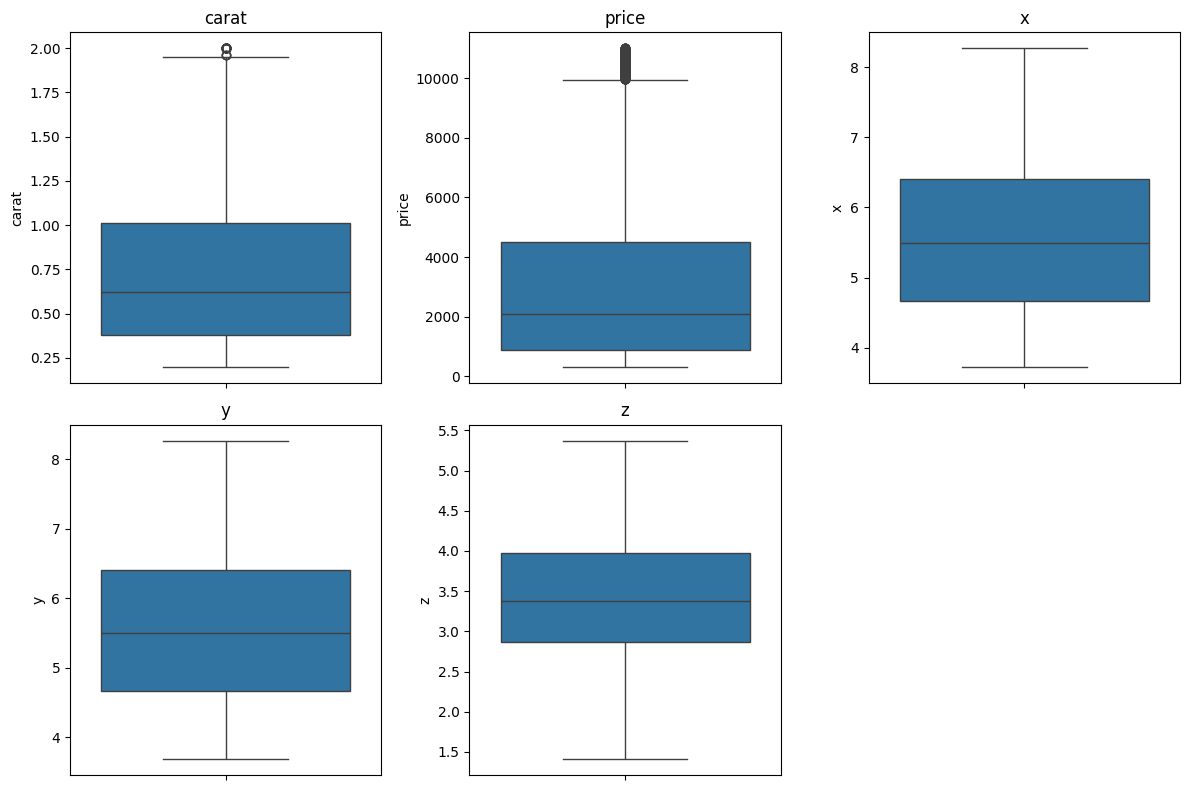

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['carat','price','x','y','z']

plt.figure(figsize=(12,8))
for i, col in enumerate(cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
cols = ['carat', 'price', 'x', 'y', 'z']
for col in cols:
    print(f"Skewness of {col}: {df[col].skew()}")

Skewness of carat: 0.6592863186019396
Skewness of price: 1.1264046302510622
Skewness of x: 0.21927766692460596
Skewness of y: 0.21378017420201073
Skewness of z: 0.22006425788005973


In [26]:
import numpy as np

df['price'] = np.log1p(df['price'])

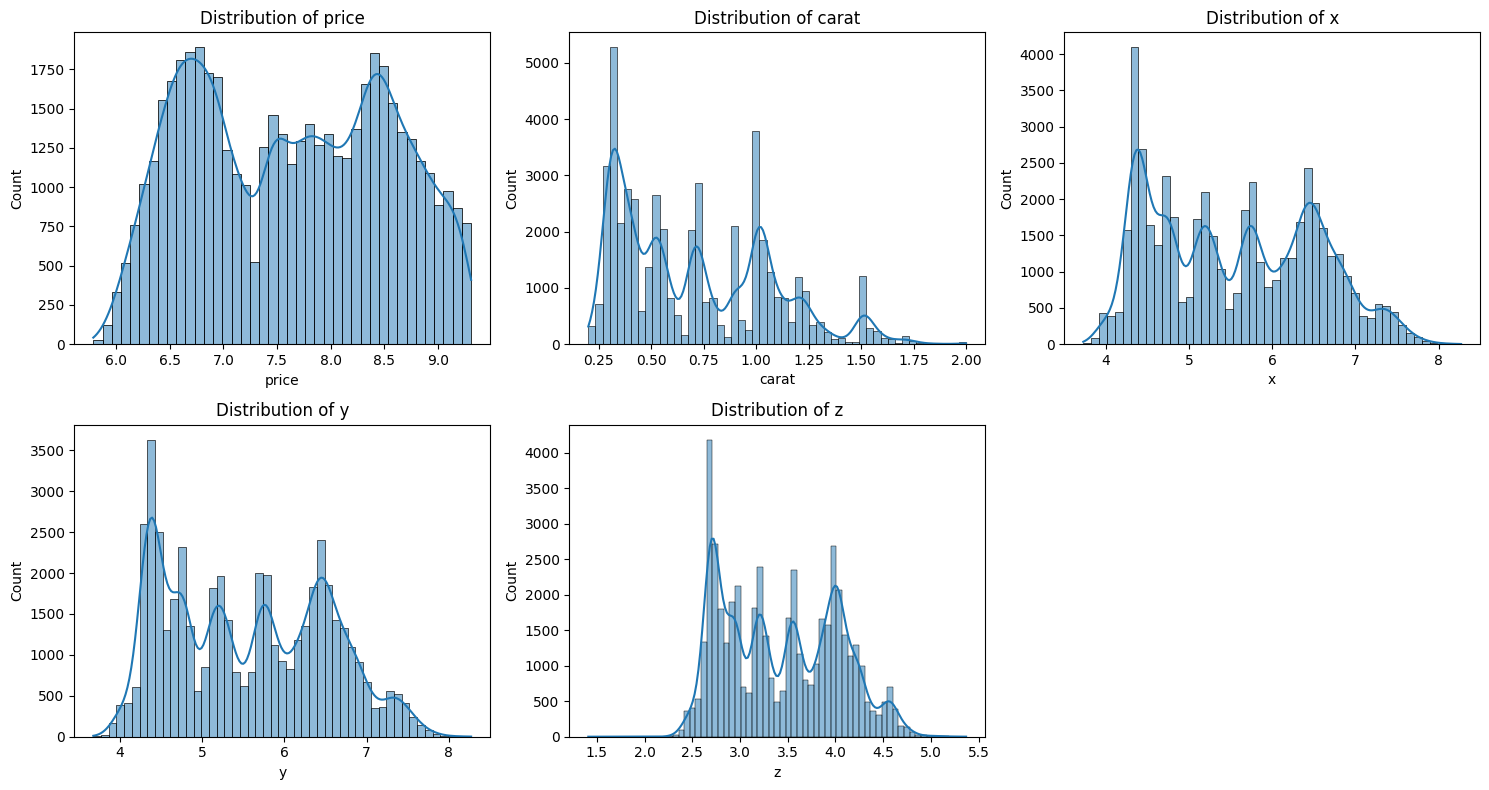

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['price','carat','x','y','z']

plt.figure(figsize=(15,8))
for i, col in enumerate(cols):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

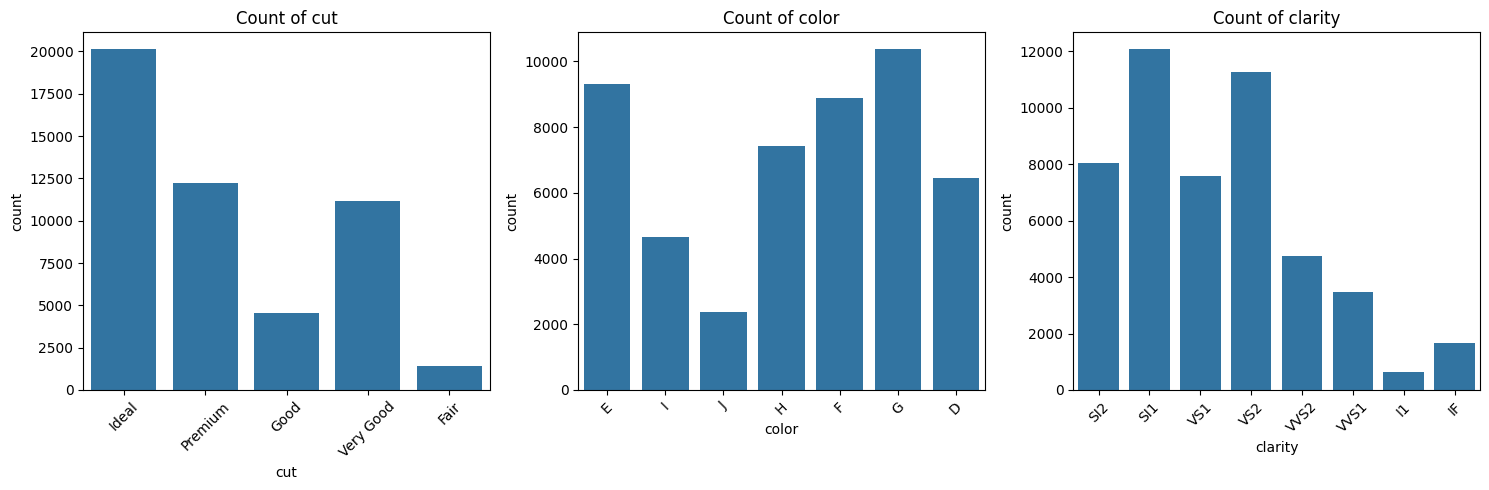

In [ ]:
cat_cols = ['cut','color','clarity']

plt.figure(figsize=(15,5))
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

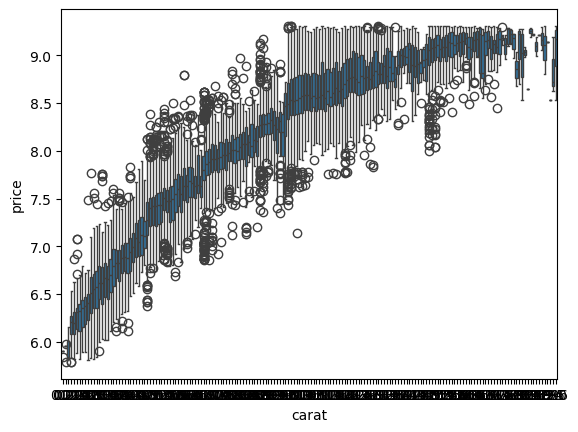

In [ ]:
sns.boxplot(x=df['carat'], y=df['price'])
plt.show()

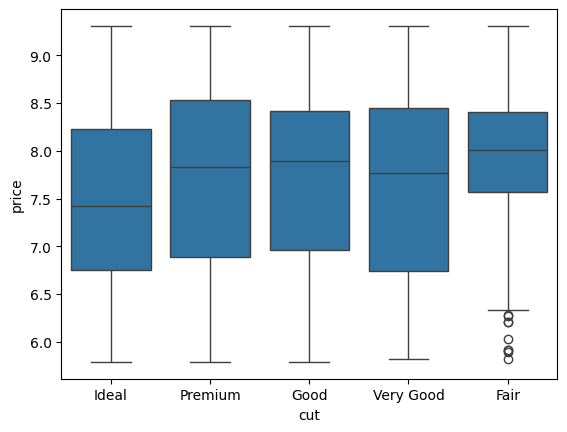

In [ ]:
sns.boxplot(x='cut', y='price', data=df)
plt.show()

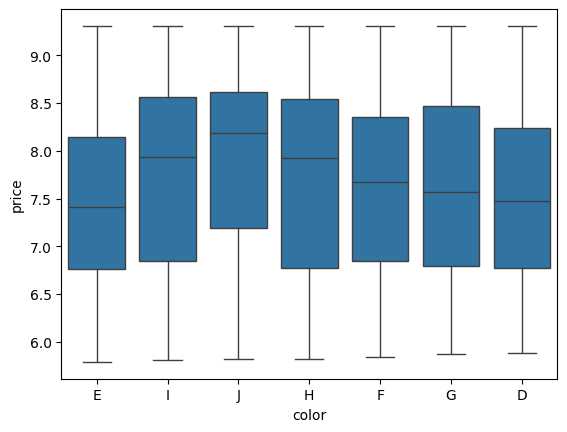

In [ ]:
sns.boxplot(x='color', y='price', data=df)
plt.show()

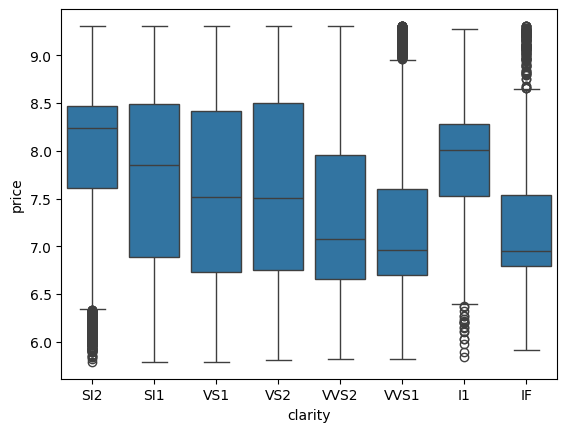

In [ ]:
sns.boxplot(x='clarity', y='price', data=df)
plt.show()

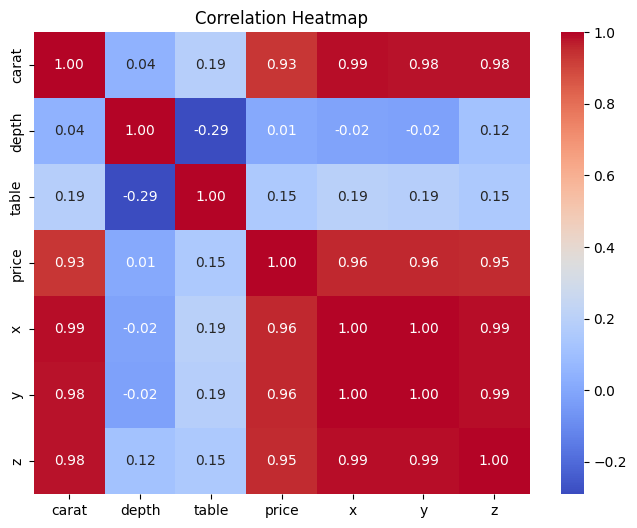

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

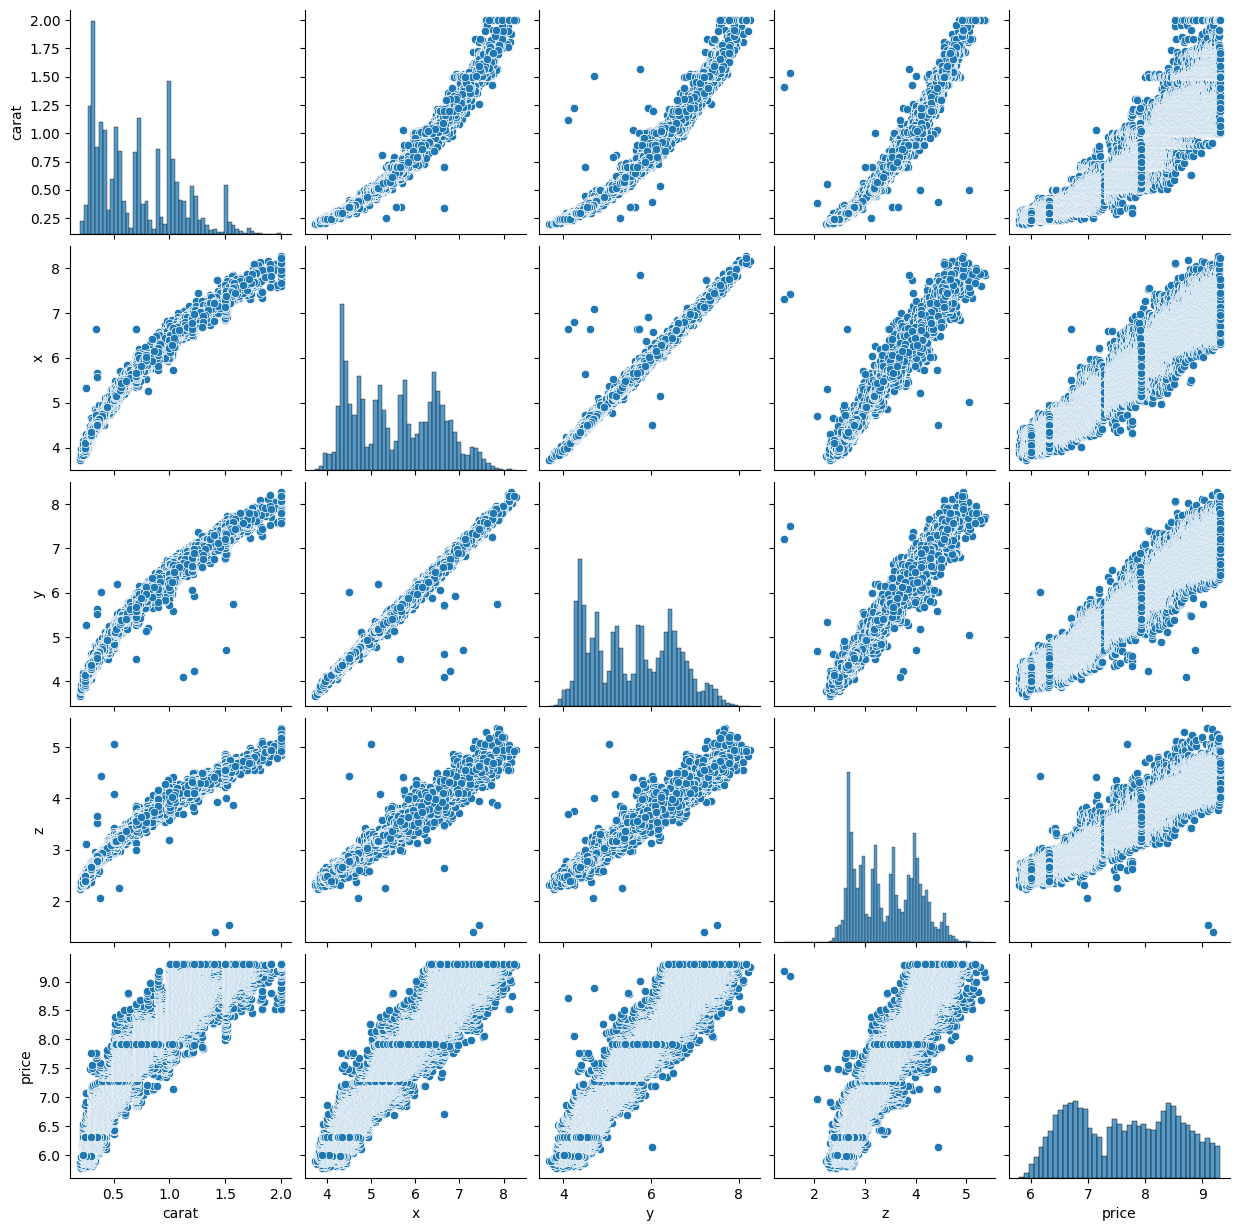

In [ ]:
sns.pairplot(df[['carat','x','y','z','price']])
plt.show()

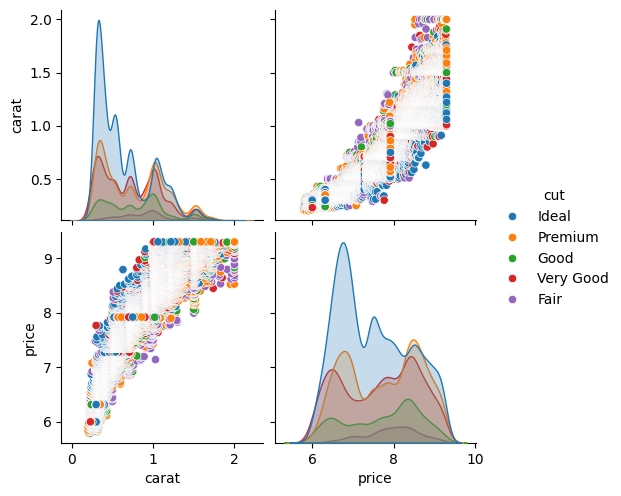

In [ ]:
sns.pairplot(df,
             vars=['carat','price'],
             hue='cut')
plt.show()

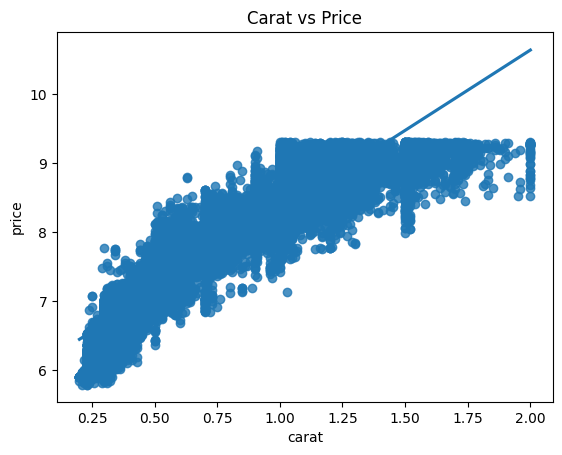

In [ ]:
sns.regplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

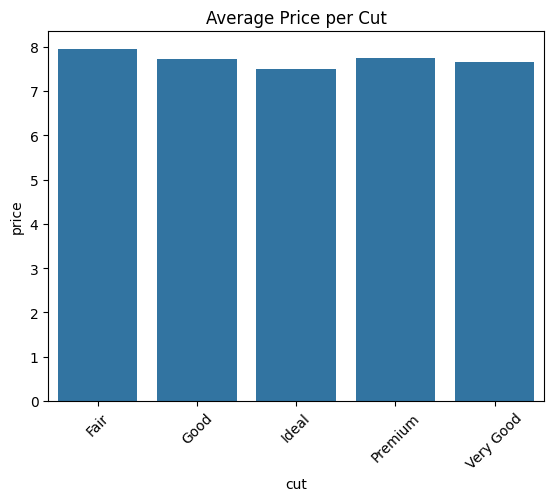

In [ ]:
avg_cut = df.groupby('cut')['price'].mean().reset_index()

sns.barplot(x='cut', y='price', data=avg_cut)
plt.title("Average Price per Cut")
plt.xticks(rotation=45)
plt.show()

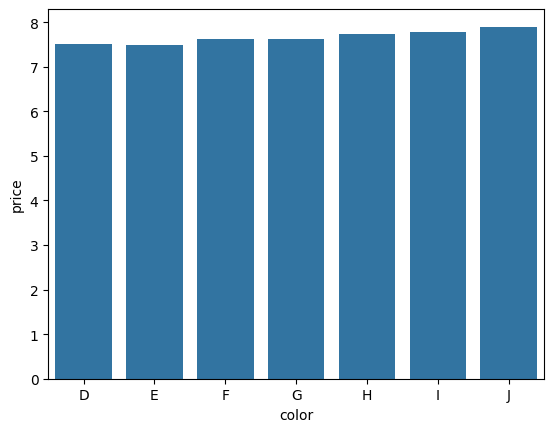

In [ ]:
avg_color = df.groupby('color')['price'].mean().reset_index()
sns.barplot(x='color', y='price', data=avg_color)
plt.show()



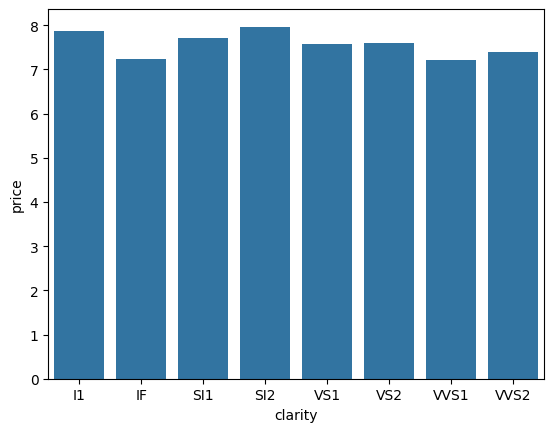

In [ ]:
avg_clarity = df.groupby('clarity')['price'].mean().reset_index()
sns.barplot(x='clarity', y='price', data=avg_clarity)
plt.show()

In [27]:
conversion_rate = 83

df['price_inr'] = df['price'] * conversion_rate

In [28]:
df["price_inr"].head()

,price_inr
0,480.566694
1,480.566694
2,480.820129
3,482.572834
4,482.820226


In [29]:
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])
def carat_category(carat):
    if carat < 0.5:
        return "Light"
    elif carat <= 1.5:
        return "Medium"
    else:
        return "Heavy"

df['carat_category'] = df['carat'].apply(carat_category)

In [30]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio',
       'carat_category'],
      dtype='object')

In [31]:
df["carat_category"].head()

,carat_category
0,Light
1,Light
2,Light
3,Light
4,Light


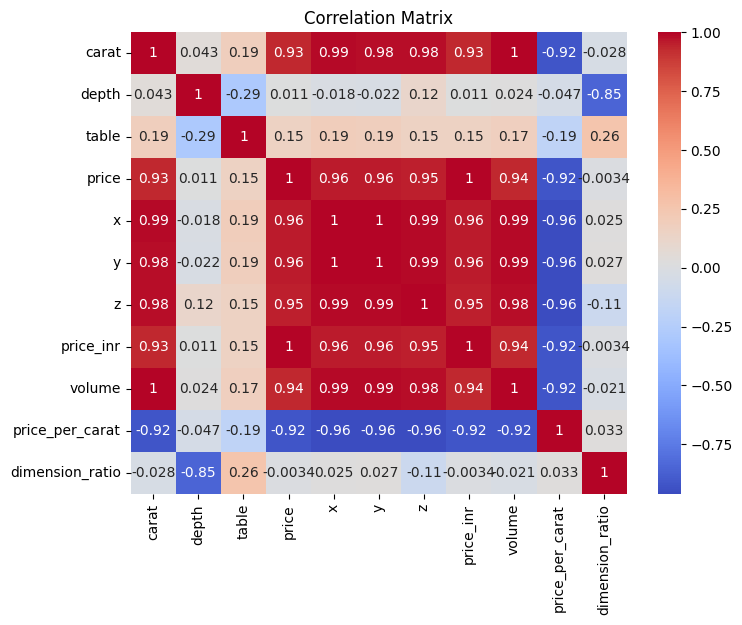

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Separate features and target
x = df.drop('price', axis=1)
y = df['price']

# Identify categorical columns
categorical_cols = x.select_dtypes(include='object').columns

# Apply Label Encoding
le = LabelEncoder()

for col in categorical_cols:
    x[col] = le.fit_transform(x[col])

# Train Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(x, y)

# Get feature importance
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature    Importance
9         price_inr  1.000000e+00
8                 z  7.697522e-09
4             depth  7.459638e-09
11  price_per_carat  6.078395e-09
2             color  4.834105e-09
0             carat  4.101015e-09
12  dimension_ratio  3.921505e-09
3           clarity  3.669027e-09
10           volume  3.506536e-09
6                 x  2.693920e-09
7                 y  2.198077e-09
5             table  2.114739e-09
1               cut  9.050468e-10
13   carat_category  6.721605e-11


In [35]:
df=df.drop(["carat_category","table","volume","dimension_ratio","price_per_carat","depth",],axis=1)

In [36]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["cut"]=le.fit_transform(df["cut"])
df["color"]=le.fit_transform(df["color"])
df["clarity"]=le.fit_transform(df["clarity"])

df.head()

,carat,cut,color,clarity,price,x,y,z,price_inr
0,0.23,2,1,3,5.789960,3.95,3.98,2.43,480.566694
1,0.21,3,1,2,5.789960,3.89,3.84,2.31,480.566694
2,0.23,1,1,4,5.793014,4.05,4.07,2.31,480.820129
3,0.29,3,5,5,5.814131,4.20,4.23,2.63,482.572834
4,0.31,1,6,3,5.817111,4.34,4.35,2.75,482.820226


In [38]:
from sklearn.model_selection import train_test_split
x = df.drop(['price','price_inr'], axis=1)
y = df['price']
#x=df.drop("price",axis=1)
#y=df["price"]
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=42)


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

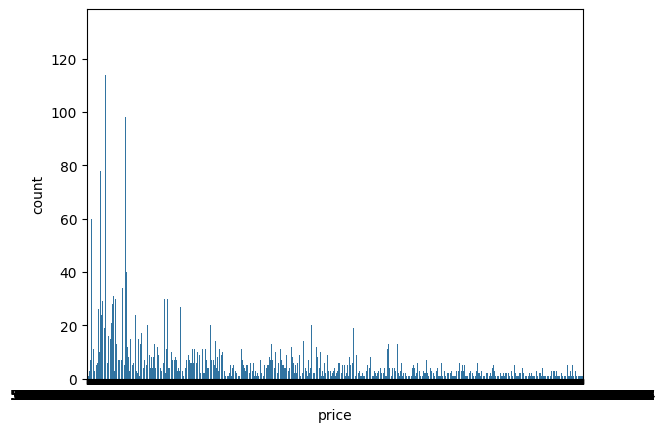

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='price', data=df)
plt.show()

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [41]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "xgb": XGBRegressor()
}

In [42]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append([name, mae, mse, rmse, r2])

In [43]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model","MAE","MSE","RMSE","R2 Score"
])

print(results_df)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.154636  0.041284  0.203184  0.949305
1      Decision Tree  0.082867  0.014607  0.120859  0.982063
2      Random Forest  0.063137  0.007909  0.088931  0.990288
3                KNN  0.076398  0.011688  0.108110  0.985648
4                xgb  0.062302  0.007404  0.086044  0.990909


In [44]:
import pickle

pickle.dump(models["xgb"], open("diamond_price_model.pkl", "wb"))

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=x_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)
y_pred_ann = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 2.5957 - mae: 0.8349 - val_loss: 0.0645 - val_mae: 0.1891
Epoch 2/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0505 - mae: 0.1721 - val_loss: 0.0488 - val_mae: 0.1656
Epoch 3/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0382 - mae: 0.1501 - val_loss: 0.0394 - val_mae: 0.1493
Epoch 4/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0314 - mae: 0.1360 - val_loss: 0.0292 - val_mae: 0.1303
Epoch 5/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0278 - mae: 0.1275 - val_loss: 0.0272 - val_mae: 0.1252
Epoch 6/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0262 - mae: 0.1235 - val_loss: 0.0264 - val_mae: 0.1229
Epoch 7/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0246 - mae: 0.1196 - val_loss: 0.0237 - val_mae: 0.1165
Epoch 8/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0235 - mae: 0.1163 - val_loss: 0.0207 - val_mae: 0.1083
Epoch 9/50
867/867 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - lo

In [46]:
mae = mean_absolute_error(y_test, y_pred_ann)
mse = mean_squared_error(y_test, y_pred_ann)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ann)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Absolute Error: 0.0776
Mean Squared Error: 0.0104
Root Mean Squared Error: 0.1018
R-squared: 0.9873


Clustering using kmeans and dbscan

In [47]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

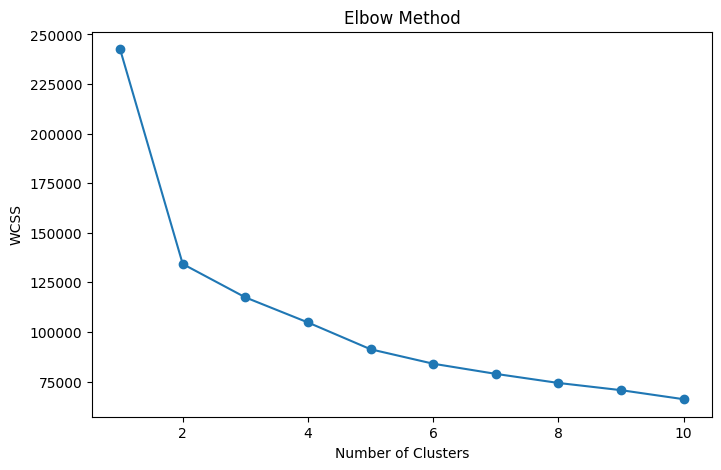

In [48]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [49]:
x_scaled=scaler.fit_transform(x)


In [50]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

models = {
    "KMeans": KMeans(n_clusters=2, random_state=42),

    "DBSCAN": DBSCAN(eps=0.5, min_samples=5)
}

for name, model in models.items():

    labels = model.fit_predict(x_scaled)

    # Silhouette score works only if more than 1 cluster
    if len(set(labels)) > 1:
        score = silhouette_score(x_scaled, labels)
        print(name, "Silhouette Score:", score)
    else:
        print(name, "Cannot compute silhouette score")

KMeans Silhouette Score: 0.37455641892988667
DBSCAN Silhouette Score: -0.2676679930532191


In [51]:

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_train)

    score = silhouette_score(x_train, labels)
    print("Clusters:", k, "Silhouette Score:", score)

Clusters: 2 Silhouette Score: 0.37513496061777124
Clusters: 3 Silhouette Score: 0.2463236235981891
Clusters: 4 Silhouette Score: 0.20875642785112597
Clusters: 5 Silhouette Score: 0.22320076360340724
Clusters: 6 Silhouette Score: 0.2111427033887573
Clusters: 7 Silhouette Score: 0.21386240326343284
Clusters: 8 Silhouette Score: 0.21040180104229672
Clusters: 9 Silhouette Score: 0.20219878199300145


In [52]:
kmeans = KMeans(n_clusters=4, random_state=42)

x_scaled = scaler.transform(x)

kmeans_labels = kmeans.fit_predict(x_scaled)

kmeans_score = silhouette_score(x_scaled, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.20857358610113344


In [53]:
db = DBSCAN(eps=0.5, min_samples=5)

db_labels = db.fit_predict(x_scaled)

# Remove noise points
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_score = silhouette_score(x_scaled[mask], db_labels[mask])
else:
    db_score = -1

print("DBSCAN Silhouette Score:", db_score)

DBSCAN Silhouette Score: -0.2563227571810572


In [54]:
import pickle

pickle.dump(kmeans, open("diamond_cluster_model.pkl","wb"))

In [55]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(x)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])

df['Cluster'] = kmeans_labels
pca_df['Cluster'] = df['Cluster']

/tmp/ipykernel_1052/3455823863.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


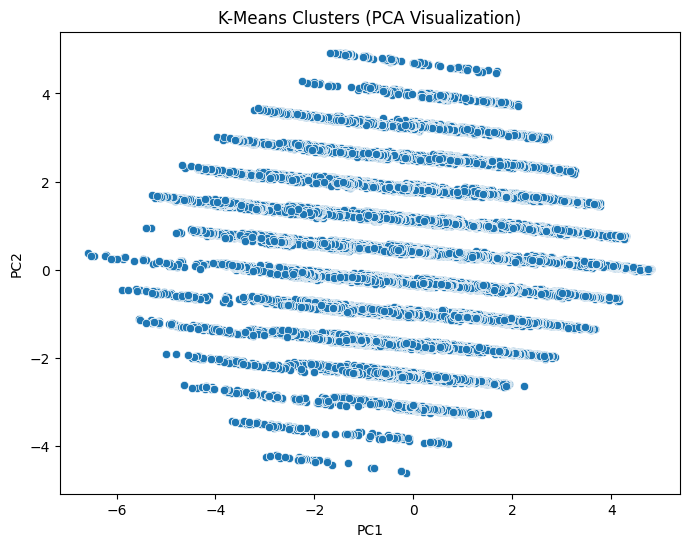

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',

    data=pca_df,
    palette='Set1'
)

plt.title("K-Means Clusters (PCA Visualization)")
plt.show()

In [57]:
df['Cluster']=kmeans_labels
cluster_summary = df.groupby('Cluster')[['price','carat','cut']].mean()

print(cluster_summary)

            price     carat       cut
Cluster                              
0        8.433925  1.025114  1.527501
1        6.873303  0.390316  2.553914
2        8.472909  1.054953  3.488196
3        7.001349  0.466548  2.513070


In [58]:
cluster_names = {
    0: "Affordable Small Diamonds",
    1: "Mid-range Balanced Diamonds",
    2: "Premium Heavy Diamonds"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

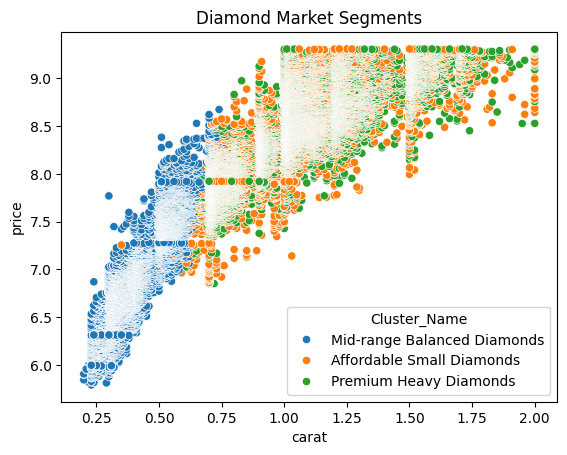

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='carat', y='price', hue='Cluster_Name')
plt.title("Diamond Market Segments")
plt.show()

In [61]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 143.1 MB/s eta 0:00:00
--2026-03-21 11:57:07--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-21 11:57:07--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-21T12%3A49%3A14Z&rscd=attachment%3B+filename%3Dclo

In [62]:
%%writefile model.py
import streamlit as st
import pandas as pd
import pickle

# Load trained models
price_model = pickle.load(open("diamond_price_model.pkl", "rb"))
cluster_model = pickle.load(open("diamond_cluster_model.pkl", "rb"))

st.title("💎 Diamond Price Prediction & Market Segmentation")

# Sidebar menu
menu = st.sidebar.selectbox(
    "Select Module",
    ["Price Prediction", "Market Segment Prediction"]
)

# Input fields
st.subheader("Enter Diamond Details")

carat = st.number_input("Carat", min_value=0.0)
x = st.number_input("Length (x)")
y = st.number_input("Width (y)")
z = st.number_input("Depth (z)")

cut = st.selectbox("Cut", ["Fair","Good","Very Good","Premium","Ideal"])
color = st.selectbox("Color", ["D","E","F","G","H","I","J"])
clarity = st.selectbox("Clarity", ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"])

# Convert categorical values (example encoding)
cut_map = {"Fair":0,"Good":1,"Very Good":2,"Premium":3,"Ideal":4}
color_map = {"D":0,"E":1,"F":2,"G":3,"H":4,"I":5,"J":6}
clarity_map = {"I1":0,"SI2":1,"SI1":2,"VS2":3,"VS1":4,"VVS2":5,"VVS1":6,"IF":7}

cut_val = cut_map[cut]
color_val = color_map[color]
clarity_val = clarity_map[clarity]

features = [[carat, x, y, z, cut_val, color_val, clarity_val]]

# -------------------------------
# PRICE PREDICTION
# -------------------------------
if menu == "Price Prediction":

    if st.button("Predict Price"):
        prediction = price_model.predict(features)

        st.success(f"💰 Predicted Diamond Price: ₹ {round(prediction[0],2)}")


# -------------------------------
# CLUSTER PREDICTION
# -------------------------------
if menu == "Market Segment Prediction":

    if st.button("Predict Cluster"):
        cluster = cluster_model.predict(features)

        cluster_names = {
            0: "Affordable Small Diamonds",
            1: "Mid-range Balanced Diamonds",
            2: "Premium Heavy Diamonds"
        }

        name = cluster_names.get(cluster[0],"Unknown")

        st.success(f"Cluster: {cluster[0]}")
        st.info(f"Market Segment: {name}")


Writing model.py


In [63]:
!streamlit run /content/model.py &>/content/logs.txt &

In [64]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://mambo-baseball-pope-korea.trycloudflare.com
